# Problema 1 - Audio MNIST

## Descripción:

En este problema, se presenta un conjunto de datos que contiene clips de audio correspondientes a dígitos
hablados del 0 al 9.

## Dataset:

https://www.tensorflow.org/datasets/catalog/spoken_digit

El dataset proporcionado incluye un total de 2500 clips de audio correspondientes a 5 locutores distintos,
50 clips por dígito por locutor

## Objetivo:
 
Utilizando el dataset proporcionado, el objetivo es construir un modelo de clasificación utilizando redes
neuronales que pueda inferir con precisión el dígito correspondiente dado un clip de audio. Se deben
entrenar y evaluar modelos utilizando técnicas adecuadas de validación y métricas de evaluación de
clasificación

Se solicita entrenar dos modelos de distintas arquitecturas y comparar los resultados:
● Modelo convolucional sobre los espectrogramas de los clips.
● Modelo recurrente sobre los espectrogramas de los clips.


### Importar librerías

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from IPython import display
import pandas as pd
from tensorflow.keras import layers
from tensorflow.keras import models
import seaborn as sns
import os
import sox
import scipy
import soundfile as sf

In [ ]:
# Configurar para que TensorFlow utilice la GPU por defecto
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que TensorFlow asigne memoria dinámicamente
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Especificar la GPU por defecto
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Manejar error
        print(e)

2025-06-10 18:25:37.890513: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-10 18:25:37.951800: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-10 18:25:37.952325: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


1 Physical GPUs, 1 Logical GPUs


2025-06-10 18:25:37.970322: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-10 18:25:37.970891: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-10 18:25:37.971204: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-10 18:25:38.243994: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-10 18:25:38.244670: I tensorflow/compile

### Descargar dataset:

Se separa el dataset en 80% para test y 20% para validacion, siendo 2000 datos y 500

In [ ]:
df_train, df_val  = tfds.load('spoken_digit', with_info=False, as_supervised=False,shuffle_files=True,split=['train[:80%]', 'train[80%:]'])

In [ ]:
train_etiquetas = np.array([])
train_largo_señal = np.array([])
for muestra in df_train:
  etiqueta = muestra['label']
  audio = muestra['audio']
  train_etiquetas = np.append(train_etiquetas,etiqueta)
  train_largo_señal = np.append(train_largo_señal,len(audio))

In [ ]:
def val_abs(val):
    return f"{val:.1f}%"
etiquetas,porciones = np.unique(train_etiquetas,return_counts=True)
colores = sns.color_palette('pastel')
plt.pie(x=porciones,autopct=val_abs,labels=etiquetas,colors=colores,startangle=90)
plt.title('Balanceo de clases')
plt.show()

In [ ]:
sns.histplot(train_largo_señal)
plt.title('Histograma: extensión de los audios')
plt.show()

### Normalizar los audios

In [ ]:
def normalize_audio_length(example, target_length=8000):
    audio = example['audio']
    current_length = tf.shape(audio)[0]
    
    # Agregar padding el audio mide menos de 8000hz
    padding_needed = tf.maximum(target_length - current_length, 0)
    audio = tf.pad(audio, [[0, padding_needed]])
    
    # Truncar si es más largo
    audio = audio[:target_length]
    
    return {
        'audio': audio,
        'label': example['label'],
        'audio/filename': example['audio/filename'],
    }


df_train_norm = df_train.map(normalize_audio_length, num_parallel_calls=tf.data.AUTOTUNE)
df_val_norm = df_val.map(normalize_audio_length, num_parallel_calls=tf.data.AUTOTUNE)


for example in df_train_norm.take(1):
    print("Audio shape:", example['audio'].shape)
    print("Label:", example['label'].numpy())
    print("Filename:", example['audio/filename'].numpy().decode())

Audio shape: (8000,)
Label: 2
Filename: 2_nicolas_23.wav


2025-06-10 18:25:39.145436: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


# Convertir formas de onda a espectrogramas

Las formas de onda en el conjunto de datos están representadas en el dominio del tiempo. A continuación, se transforman las formas de onda de señales del dominio del tiempo a señales del dominio tiempo-frecuencia al calcular la [transformada de Fourier de corto tiempo (STFT)](https://en.wikipedia.org/wiki/Short-time_Fourier_transform) para convertir las formas de onda en [espectrogramas](https://en.wikipedia.org/wiki/Spectrogram), que muestran cambios de frecuencia a lo largo del tiempo y pueden ser representados como imágenes 2D.

La STFT (`tf.signal.stft`) divide la señal en ventanas de tiempo y ejecuta una transformada de Fourier en cada ventana, preservando parte de la información temporal, y devolviendo un tensor 2D.

Se define una función de utilidad para convertir formas de onda a espectrogramas:

- Las formas de onda deben tener la misma longitud, de modo que cuando se conviertan en espectrogramas, los resultados tengan dimensiones similares.
- Al llamar a `tf.signal.stft`, elegir los parámetros `frame_length` y `frame_step` de tal manera que la "imagen" de espectrograma generada sea casi cuadrada. Para obtener más información sobre la elección de los parámetros de la STFT, consultar este [video de Coursera](https://www.coursera.org/lecture/audio-signal-processing/stft-2-tjEQe) sobre procesamiento de señales de audio y STFT.
- La STFT produce una matriz de números complejos que representan magnitud y fase. Sin embargo, en este tutorial solo utilizaremos la magnitud, que podemos derivar aplicando `tf.abs` en la salida de `tf.signal.stft`.

In [ ]:
def get_spectrogram(waveform):

  waveform = tf.cast(waveform, tf.float32)

  spectrogram = tf.signal.stft(waveform, frame_length=255, frame_step=128)

  spectrogram = tf.abs(spectrogram)
  
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

### Escuchar distintos ejemplos de numeros de Dataset

In [ ]:
for example_audio in df_train_norm.take(3):
    audio = tf.cast(example_audio['audio'], float)
    waveform = audio
    spectrogram = get_spectrogram(waveform)

    print('Label:', int(example_audio['label']))
    print('Waveform shape:', waveform.shape)
    print('Spectrogram shape:', spectrogram.shape)
    print('Audio playback')
    display.display(display.Audio(waveform, rate=8000))

Label: 2
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


Label: 1
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


Label: 9
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


2025-06-10 18:25:39.420993: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Grafico de ejemplos de las seniales de onda de los numeros

2025-06-10 18:25:39.713610: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


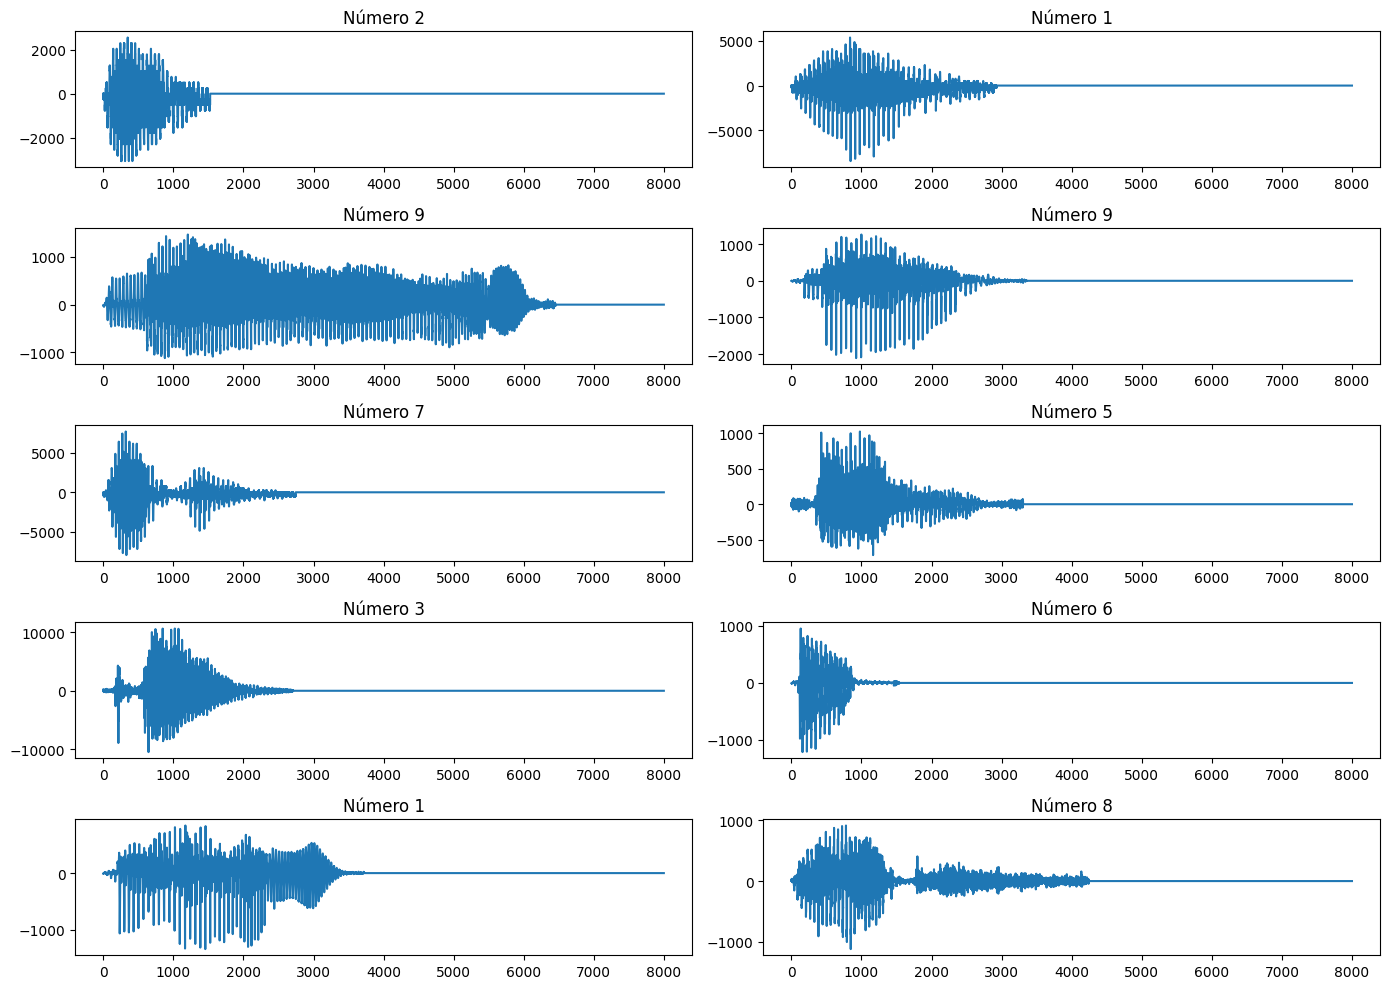

In [ ]:
plt.figure(figsize=(14, 10))

for i, example in enumerate(df_train_norm.take(10)):
    audio = example['audio'].numpy()
    label = example['label'].numpy()

    plt.subplot(5, 2, i + 1)
    plt.plot(audio)
    plt.title(f'Número {label}')

plt.tight_layout()
plt.show()

### Se promedian todas las seniales del mismo numero
Esto para comprobar si todavia son comprensibles para el oido

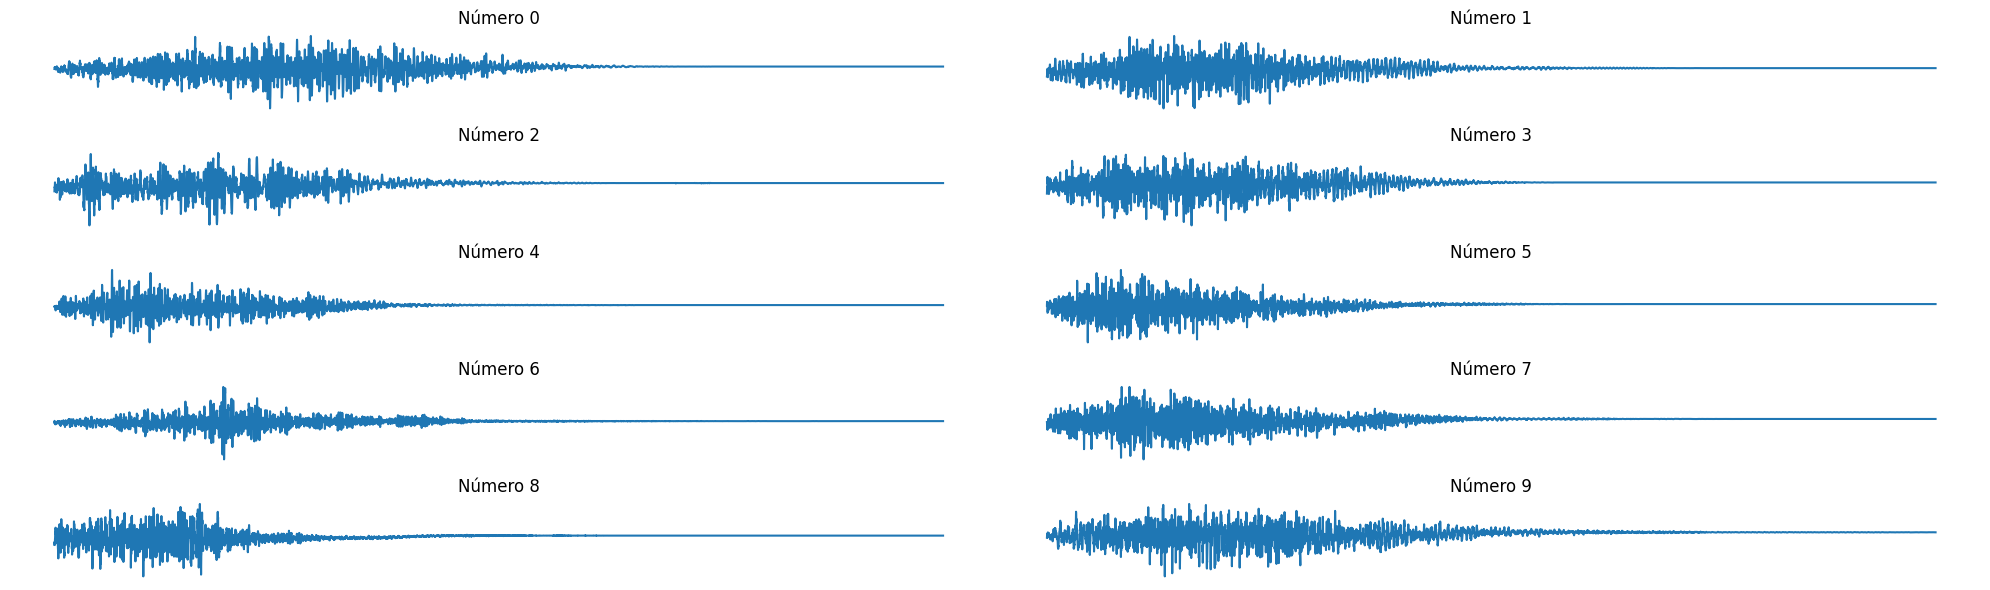

In [ ]:
audios_numeros = {i: [] for i in range(10)}

for example in df_train_norm:
    audio = example['audio'].numpy()
    label = example['label'].numpy()
    audios_numeros[label].append(audio)

promedios_seniales = []

plt.figure(figsize=(20, 6))
for i in range(10):
    seniales = audios_numeros[i]
    
    if len(seniales) == 0:
        continue

    longitud_promedio = int(np.mean([len(s) for s in seniales]))

    seniales_ajustadas = []
    for senial in seniales:
        if len(senial) < longitud_promedio:
            senial = np.pad(senial, (0, longitud_promedio - len(senial)), mode='constant')
        else:
            senial = senial[:longitud_promedio]
        seniales_ajustadas.append(senial)

    stacked = np.stack(seniales_ajustadas)
    mean_signal = np.mean(stacked, axis=0)
    promedios_seniales.append(mean_signal)

    plt.subplot(5, 2, i+1)
    plt.plot(mean_signal)
    plt.title(f"Número {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Se prueba esuchar los promedios de las distitnas seniales de cada numero

In [ ]:
for cant_audio in range(len(promedios_seniales)): print(f"audio numero:{cant_audio}"),display.display(display.Audio(promedios_seniales[cant_audio], rate=8000))

audio numero:0


audio numero:1


audio numero:2


audio numero:3


audio numero:4


audio numero:5


audio numero:6


audio numero:7


audio numero:8


audio numero:9


### Graficar la diferenica entre la onda y el espectograma de la misma

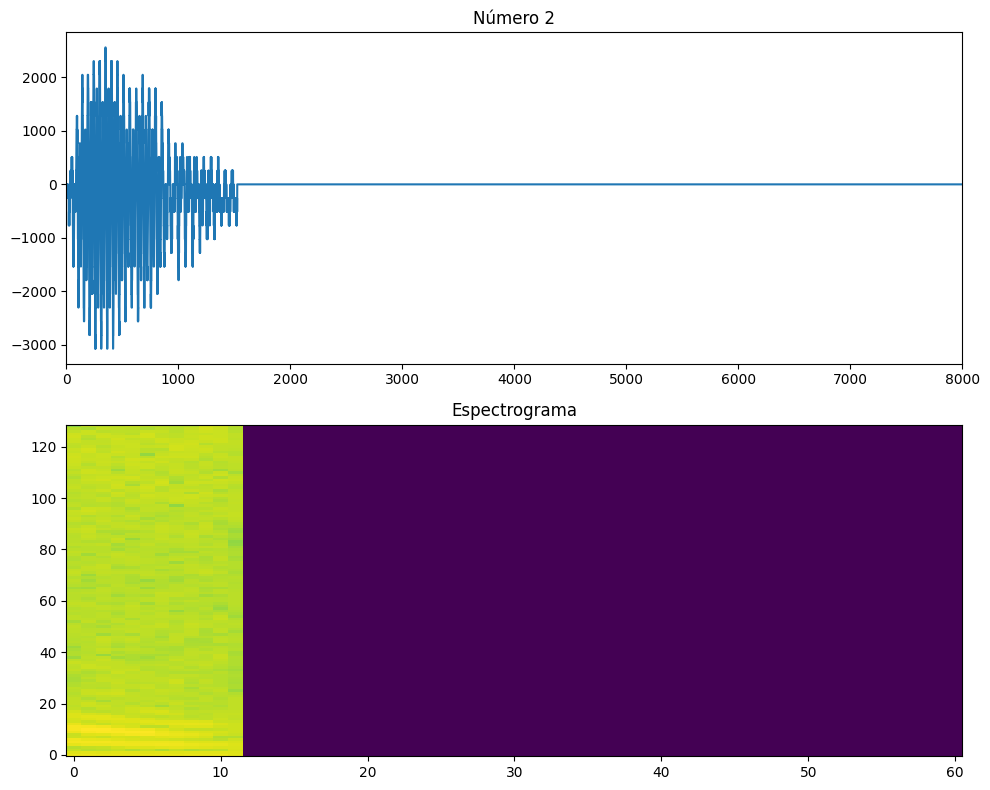

In [ ]:
def plot_spectrogram(spectrogram, ax):
    if spectrogram.ndim == 3:
        spectrogram = np.squeeze(spectrogram, axis=-1)
    log_spec = np.log(spectrogram.T + np.finfo(float).eps)
    height = log_spec.shape[0]
    width = log_spec.shape[1]
    X = np.arange(width)
    Y = range(height)
    ax.pcolormesh(X, Y, log_spec)


for example in df_train_norm.take(1):
    waveform = example['audio'].numpy()
    label = example['label'].numpy()
    spectrogram = get_spectrogram(waveform).numpy()

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    axes[0].plot(waveform)
    axes[0].set_title(f"Número {label}")
    axes[0].set_xlim([0, len(waveform)])

    plot_spectrogram(spectrogram, axes[1])
    axes[1].set_title("Espectrograma")

    plt.tight_layout()
    plt.show()

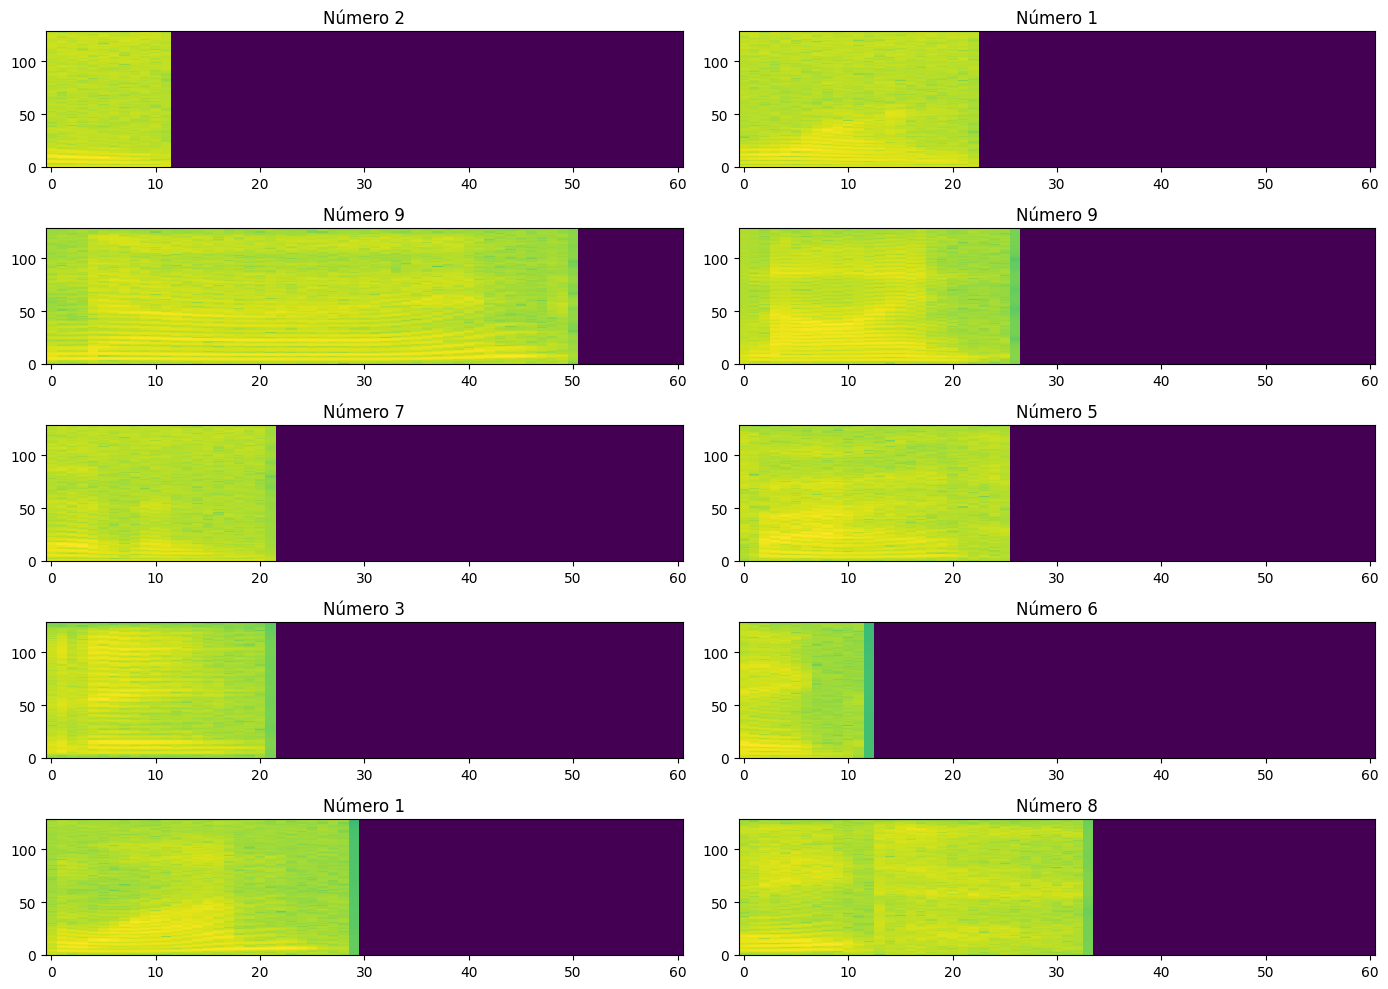

In [ ]:
plt.figure(figsize=(14, 10))

for i, example in enumerate(df_train_norm.take(10)):
    audio = example['audio'].numpy()
    label = example['label'].numpy()

    spectrogram = get_spectrogram(audio).numpy()

    ax = plt.subplot(5, 2, i + 1)
    plot_spectrogram(spectrogram, ax)
    ax.set_title(f'Número {label}')


plt.tight_layout()
plt.show()


Ahora creamos un dataset de espectrogramas utilizando la función definida.

In [ ]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda dicc: (get_spectrogram(dicc['audio']), dicc['label']),
      num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
train_spectrogram_ds = make_spec_ds(df_train_norm)
val_spectrogram_ds = make_spec_ds(df_val_norm)

In [ ]:
train_spectrogram_ds = train_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

### Dataset de espectogramas

In [ ]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

2025-06-10 18:25:43.553316: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Definimos el bache para el entrenamiento y la validacion 

In [ ]:
train_spectrogram_ds = train_spectrogram_ds.batch(50)
val_spectrogram_ds = val_spectrogram_ds.batch(50)

## Entrenamiento del Modelo convolucional

Para el modelo, se utilizará una red neuronal convolucional simple (CNN), ya que se han transformado los archivos de audio en imágenes de espectrograma.

El modelo `tf.keras.Sequential` utilizará las siguientes capas de preprocesamiento de Keras:

- `tf.keras.layers.Resizing`: para reducir la resolución de la entrada y permitir que el modelo entrene más rápido.
- `tf.keras.layers.Normalization`: para normalizar cada píxel en la imagen basándose en su media y desviación estándar.

Para la capa de Normalización, primero se debe llamar a su método `adapt` en los datos de entrenamiento para calcular las estadísticas agregadas (es decir, la media y la desviación estándar).

In [ ]:
input_shape = example_spectrograms.shape
print('Input shape:', input_shape)
num_labels = 10

norm_layer = layers.Normalization()

norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model_conv = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model_conv.summary()

Input shape: (61, 129, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 32, 32, 1)         0         
                                                                 
 normalization (Normalizati  (None, 32, 32, 1)         3         
 on)                                                             
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (

In [ ]:
model_conv.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

EPOCHS = 50
history = model_conv.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/50


2025-06-10 18:25:44.698719: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-06-10 18:25:44.891279: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-06-10 18:25:45.386743: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-06-10 18:25:45.471750: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x19dfa570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-10 18:25:45.471828: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2025-06-10 18:25:45.530719: I tensorflow/compiler/mlir/tensorflow/utils/dump_m

40/40 [==============================] - 3s 16ms/step - loss: 1.7351 - accuracy: 0.4100 - val_loss: 1.3096 - val_accuracy: 0.6280
Epoch 2/50
40/40 [==============================] - 0s 8ms/step - loss: 1.1335 - accuracy: 0.6350 - val_loss: 0.9047 - val_accuracy: 0.7260
Epoch 3/50
40/40 [==============================] - 0s 7ms/step - loss: 0.8342 - accuracy: 0.7335 - val_loss: 0.6986 - val_accuracy: 0.8060
Epoch 4/50
40/40 [==============================] - 0s 8ms/step - loss: 0.6653 - accuracy: 0.7920 - val_loss: 0.5148 - val_accuracy: 0.8520
Epoch 5/50
40/40 [==============================] - 0s 7ms/step - loss: 0.5183 - accuracy: 0.8405 - val_loss: 0.3806 - val_accuracy: 0.8900
Epoch 6/50
40/40 [==============================] - 0s 8ms/step - loss: 0.4387 - accuracy: 0.8540 - val_loss: 0.3552 - val_accuracy: 0.8980
Epoch 7/50
40/40 [==============================] - 0s 8ms/step - loss: 0.3316 - accuracy: 0.8935 - val_loss: 0.2917 - val_accuracy: 0.9180
Epoch 8/50
40/40 [============

### Resultados de la red

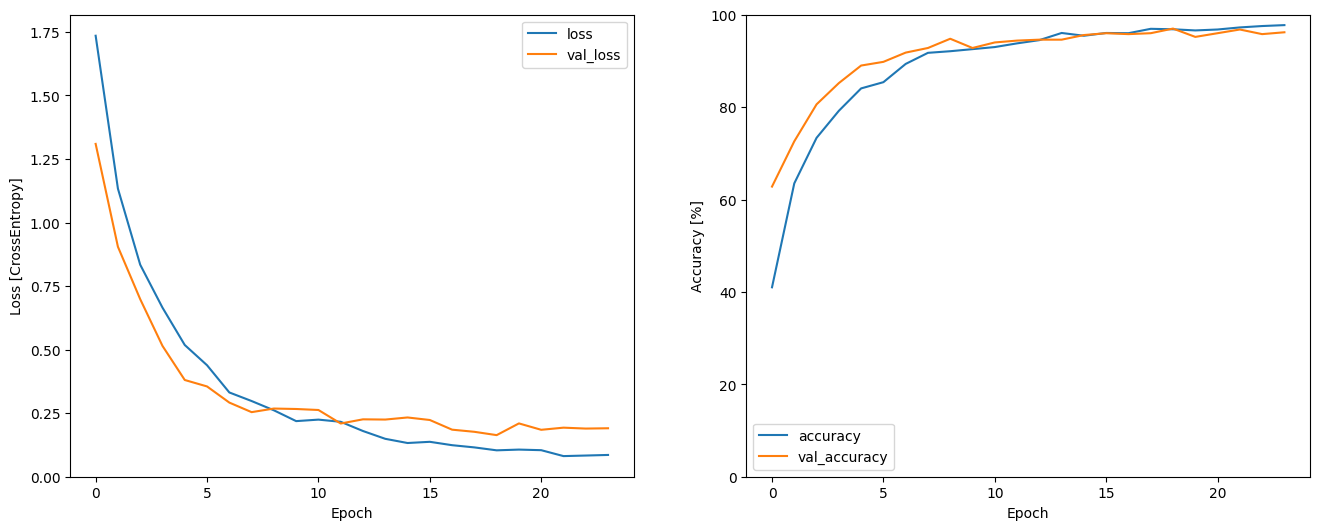

In [ ]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')
plt.show()

### Matriz de confucion

10/10 [==============================] - 0s 3ms/step


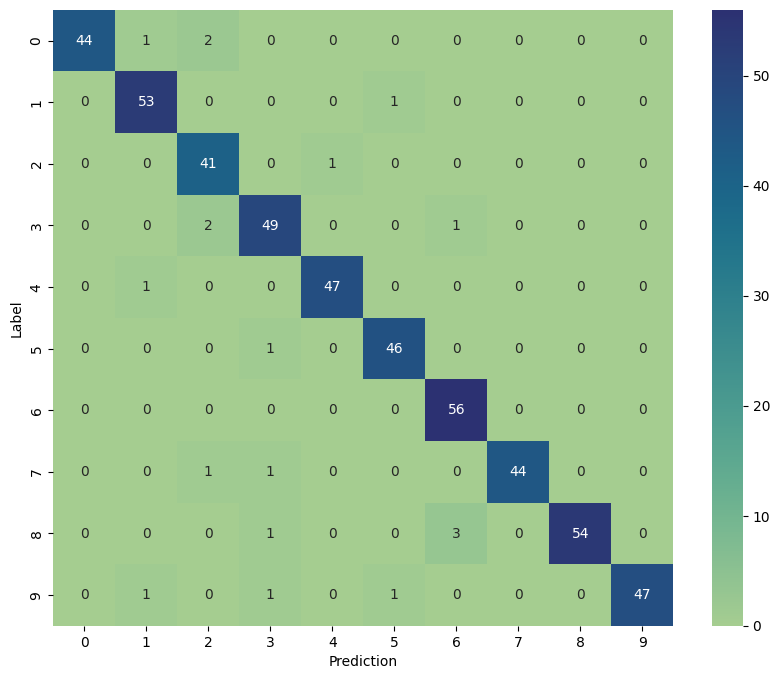

In [ ]:
label_names = [i for i in range(10)]

y_pred = model_conv.predict(val_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g', cmap='crest')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

### Probamos el modelo con audios propios

In [ ]:
def convertir_audios(directorio):
    """
    Normaliza los audios de entrada a una salida de 8k

    Los archivos de entrada se esperan en el siguiente formato: 
    
    * {num}-audio.wav --> Ejemplo: 4-audio.wav
    """ 
    directorio = 'audios_ejemplo'

    for num_audio in range(10):
        archivo = f'{num_audio}-audio.wav'
        archivo_path = os.path.join(directorio, archivo)

        audio_bin = tf.io.read_file(archivo_path)
        audio, sr = tf.audio.decode_wav(audio_bin, desired_channels=1)
        waveform = tf.squeeze(audio, axis=-1).numpy()
        sr = sr.numpy()

        target_sr = 8000
        if sr != target_sr:
            new_len = int(len(waveform) * target_sr / sr)
            waveform = scipy.signal.resample(waveform, new_len)

        sf.write(os.path.join(directorio, f'{num_audio}-audio_8k.wav'), waveform, target_sr)
         

2, 4 maso, 5 maso bien, 7

1/1 [==============================] - 0s 21ms/step


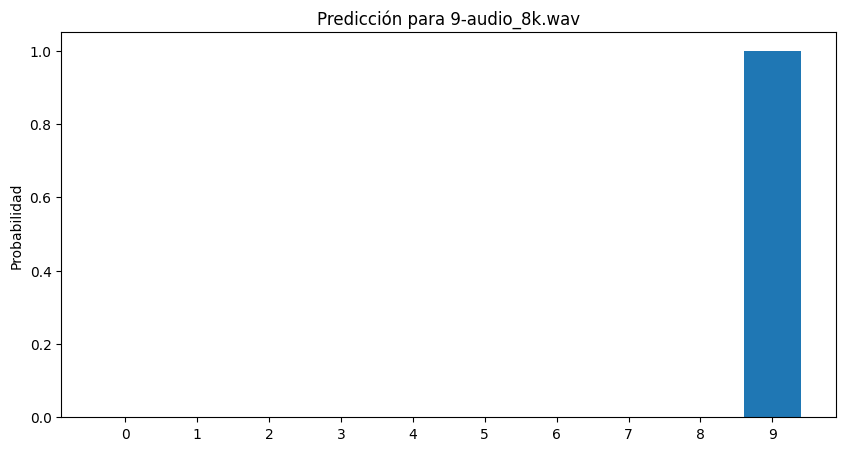

In [ ]:
def probar_audios(model,directorio):

    for audios in os.listdir(directorio):
        if audios.split("_")[1] == "8k.wav":

            file_path = os.path.join(directorio, audios)

            audio_binary = tf.io.read_file(file_path)

            audio, sample_rate = tf.audio.decode_wav(audio_binary, desired_channels=1, desired_samples=8000)

            audio = audio*32767

            waveform = tf.squeeze(audio, axis=-1)

            spectrogram = get_spectrogram(waveform)

            spectrogram = spectrogram[tf.newaxis, ..., tf.newaxis]

            prediction = model.predict(spectrogram)

            probabilities = tf.nn.softmax(prediction[0])

            label_names = [str(i) for i in range(10)]

            plt.figure(figsize=(10,5))
            plt.bar(label_names, probabilities)
            plt.title(f'Predicción para {audios}')
            plt.ylabel('Probabilidad')
            plt.show()

            display.display(display.Audio(waveform.numpy(), rate=sample_rate.numpy()))

probar_audios(model_conv,"audios_ejemplo")

## Entrenamiento del Modelo recurrente

In [ ]:
# input_shape = example_spectrograms.shape
# print('Input shape:', input_shape)
# num_labels = 10

# norm_layer = layers.Normalization()

# norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))


# model_recurrente = models.Sequential([
#     layers.Input(shape=input_shape),
#     layers.Resizing(64, 64),
#     norm_layer,
    
#     layers.Reshape((64, -1)),
    
#     layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
#     layers.Dropout(0.3),
#     layers.Bidirectional(layers.LSTM(64)),
#     layers.Dropout(0.3),
    
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(num_labels)
# ])

# model_recurrente.summary()

input_shape_rec = example_spectrograms.shape[1:-1]
print('Input shape:', input_shape_rec)
num_labels = 10

# # Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# # Fit the state of the layer to the spectrograms
# # with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label:tf.reshape(spec, (-1, input_shape_rec[-1]))    ))

model_recurrente = models.Sequential([
    layers.Input(shape=input_shape_rec),
    # Downsample the input.
    #layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_labels)
])
model_recurrente.summary()

Input shape: (61, 129, 1)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing_1 (Resizing)       (None, 64, 64, 1)         0         
                                                                 
 normalization_1 (Normaliza  (None, 64, 64, 1)         3         
 tion)                                                           
                                                                 
 reshape (Reshape)           (None, 64, 64)            0         
                                                                 
 bidirectional (Bidirection  (None, 64, 256)           197632    
 al)                                                             
                                                                 
 dropout_2 (Dropout)         (None, 64, 256)           0         
                                                                 
 bidirectional_1 (Bidirecti 

In [ ]:
model_recurrente.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

history_recurrente = model_recurrente.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=50,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=8)]
)

Epoch 1/50


40/40 [==============================] - 6s 61ms/step - loss: 1.8325 - accuracy: 0.3345 - val_loss: 1.1188 - val_accuracy: 0.6480
Epoch 2/50
40/40 [==============================] - 1s 34ms/step - loss: 0.9778 - accuracy: 0.6570 - val_loss: 0.6097 - val_accuracy: 0.8080
Epoch 3/50
40/40 [==============================] - 1s 32ms/step - loss: 0.5386 - accuracy: 0.8210 - val_loss: 0.4387 - val_accuracy: 0.8480
Epoch 4/50
40/40 [==============================] - 1s 34ms/step - loss: 0.3357 - accuracy: 0.8995 - val_loss: 0.3645 - val_accuracy: 0.8800
Epoch 5/50
40/40 [==============================] - 1s 33ms/step - loss: 0.2665 - accuracy: 0.9205 - val_loss: 0.2948 - val_accuracy: 0.9060
Epoch 6/50
40/40 [==============================] - 1s 32ms/step - loss: 0.2267 - accuracy: 0.9370 - val_loss: 0.3499 - val_accuracy: 0.9000
Epoch 7/50
40/40 [==============================] - 1s 32ms/step - loss: 0.2156 - accuracy: 0.9405 - val_loss: 0.3142 - val_accuracy: 0.9020
Epoch 8/50
40/40 [======

### Resultados de la red

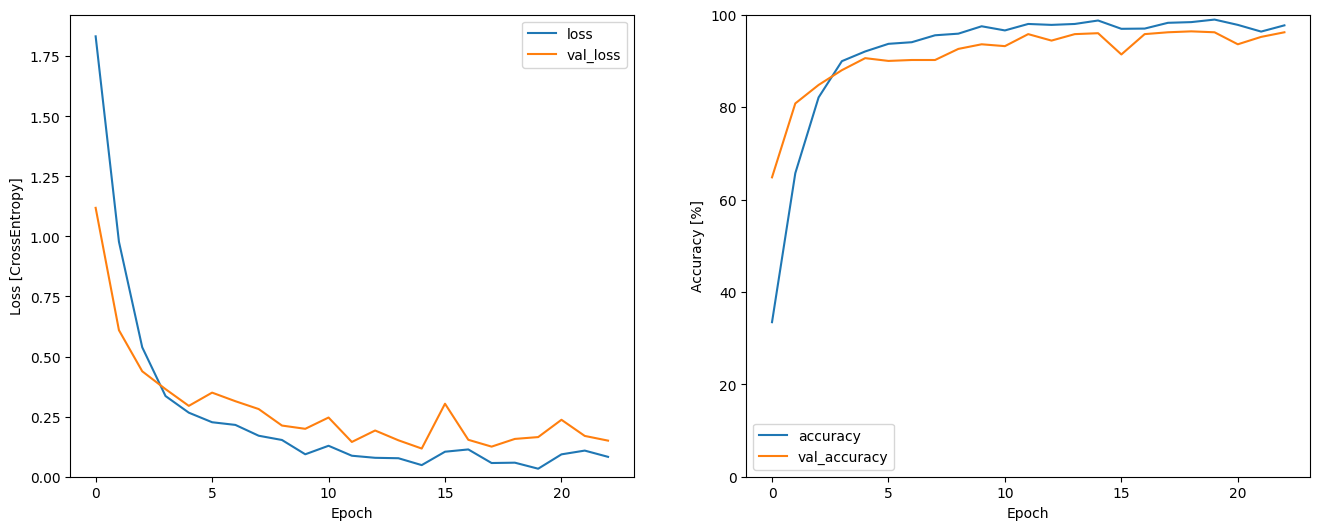

In [ ]:
metrics = history_recurrente.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history_recurrente.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history_recurrente.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')
plt.show()

## Mostrar una matriz de confusión

Utilizar una [matriz de confusión](https://developers.google.com/machine-learning/glossary#confusion-matrix) para verificar qué tan bien clasificó el modelo cada uno de los comandos en el conjunto de prueba:

10/10 [==============================] - 1s 11ms/step


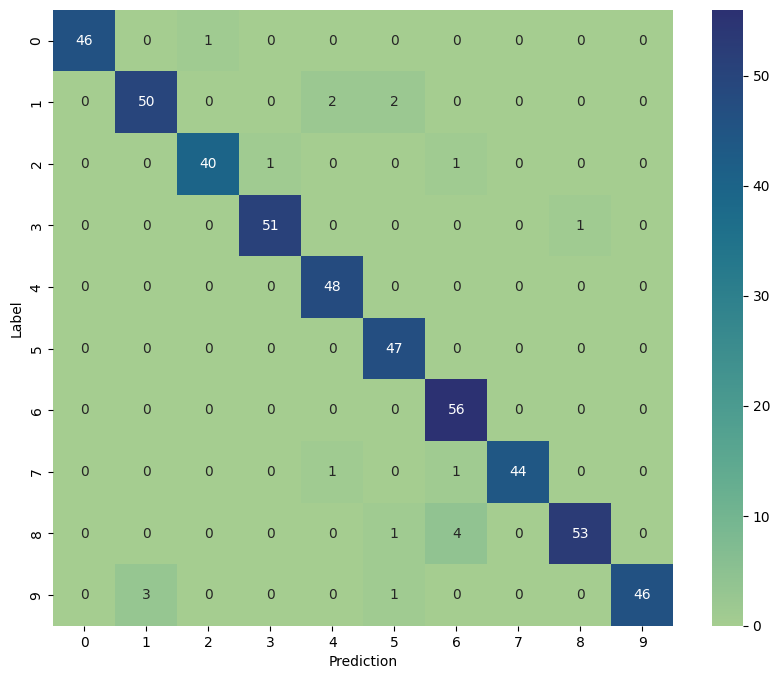

In [ ]:
label_names = [i for i in range(10)]

y_pred = model_recurrente.predict(val_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g', cmap='crest')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

### Probamos el modelo con audios propios

1/1 [==============================] - 1s 1s/step


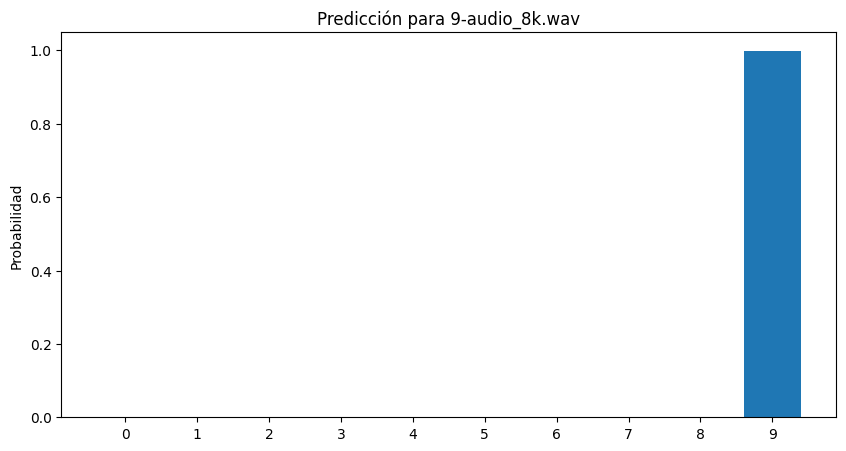

In [ ]:
probar_audios(model_recurrente,"audios_ejemplo")